### 

### Analysis of funtional, gray matter, and white matter structures

In [41]:
# import a excel file
import pandas as pd

path="/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025/"
filename="Subjects_Functional_Structural_Parameters.xlsx"

df_params = pd.read_excel(path + filename, sheet_name="Sheet1")
df_params.head()
df_params

,sub,sex,age,group,JND_P,IHD,EstimatedTotalIntraCranialVol,postcentral_lh,precentral_lh,postcentral_rh,precentral_rh,CC_Posterior,CC_Mid_Posterior,CC_Central,CC_Mid_Anterior,CC_Anterior
0,sub-01,F,25,Y,9.5600,0.534027,1.601936e+06,12151,13519,11836,13247,993.9,605.0,586.7,666.7,944.6
1,sub-02,M,27,Y,6.6900,0.570600,1.902124e+06,12527,16248,13068,16822,1015.4,425.5,400.1,439.6,922.7
2,sub-03,F,28,Y,12.9200,-0.140120,1.730076e+06,13346,14411,11596,14849,723.5,446.6,717.7,571.2,708.0
3,sub-05,F,21,Y,1.9500,0.488581,1.714908e+06,11553,13616,11595,13756,888.9,444.6,444.4,395.5,840.7
4,sub-06,F,25,Y,2.5400,0.578001,1.546827e+06,9204,12872,9348,12538,770.1,476.4,658.5,563.1,703.9
5,sub-08,F,67,O,4.4800,0.419239,1.481227e+06,10121,11646,8893,12423,865.3,547.8,621.6,368.0,758.6
6,sub-09,M,73,O,9.6300,0.246470,1.630029e+06,10915,14115,10537,13557,754.0,438.1,307.7,340.3,678.1
7,sub-10,F,64,O,7.2700,0.253942,1.502289e+06,10283,12262,9592,11687,770.8,479.8,423.9,376.6,642.0
8,sub-11,F,21,Y,1.6200,0.268078,1.397857e+06,10567,12731,9646,12031,636.7,419.8,371.8,328.2,631.0
9,sub-12,M,21,Y,3.6800,0.115833,1.680092e+06,11400,14250,11720,13795,613.9,337.5,622.0,650.6,696.6


In [42]:
# Pre-processing the data
# Relative measure of the volume mesures, for all columns, to the estimated total intracranial volume for each subject

df_params= df_params.rename(columns={"EstimatedTotalIntraCranialVol": "eTIV"})

# Assuming 'ICV' is the column name for intracranial volume in your DataFrame
colums_to_normalize = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh"] # "CC_Posterior", "CC_Mid_Posterior", "CC_Central", "CC_Mid_Anterior", "CC_Anterior"

df_params_norm = df_params.copy()
for col in colums_to_normalize:
    df_params_norm[col] = (df_params_norm[col] / df_params_norm['eTIV']) * 100  # Scale to per 1000 units of intracranial volume
df_params_norm.head()

,sub,sex,age,group,JND_P,IHD,eTIV,postcentral_lh,precentral_lh,postcentral_rh,precentral_rh,CC_Posterior,CC_Mid_Posterior,CC_Central,CC_Mid_Anterior,CC_Anterior
0,sub-01,F,25,Y,9.56,0.534027,1.601936e+06,0.758520,0.843916,0.738856,0.826937,993.9,605.0,586.7,666.7,944.6
1,sub-02,M,27,Y,6.69,0.570600,1.902124e+06,0.658580,0.854203,0.687022,0.884380,1015.4,425.5,400.1,439.6,922.7
2,sub-03,F,28,Y,12.92,-0.140120,1.730076e+06,0.771411,0.832969,0.670260,0.858286,723.5,446.6,717.7,571.2,708.0
3,sub-05,F,21,Y,1.95,0.488581,1.714908e+06,0.673680,0.793978,0.676130,0.802142,888.9,444.6,444.4,395.5,840.7
4,sub-06,F,25,Y,2.54,0.578001,1.546827e+06,0.595025,0.832155,0.604334,0.810563,770.1,476.4,658.5,563.1,703.9


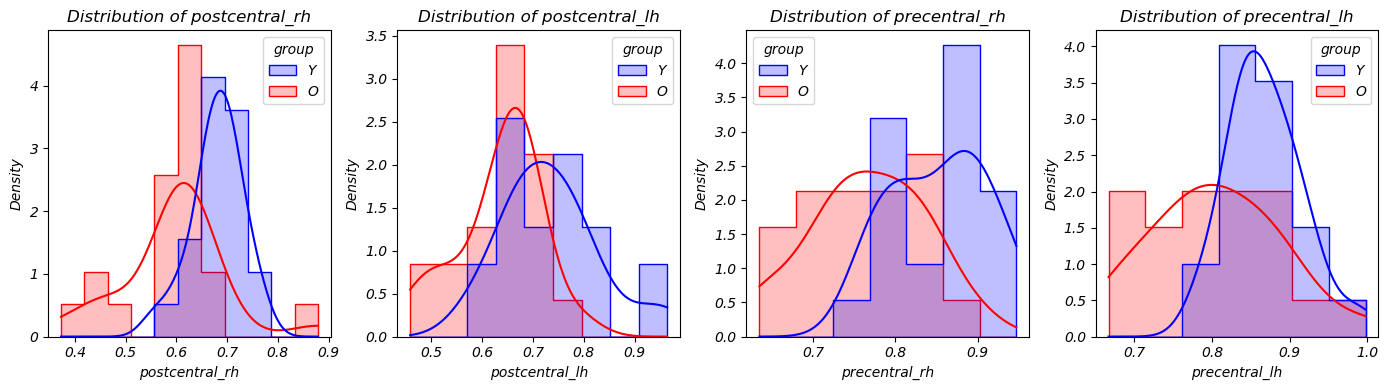

/tmp/ipykernel_120010/1263810941.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y=measure, data=df_params_norm, ax=axes[i], showfliers=False, palette=group_colors, width=0.5)
/tmp/ipykernel_120010/1263810941.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y=measure, data=df_params_norm, ax=axes[i], showfliers=False, palette=group_colors, width=0.5)
/tmp/ipykernel_120010/1263810941.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="group", y=measure, data=df_params_norm, ax=axes[i], showfliers=False, pale

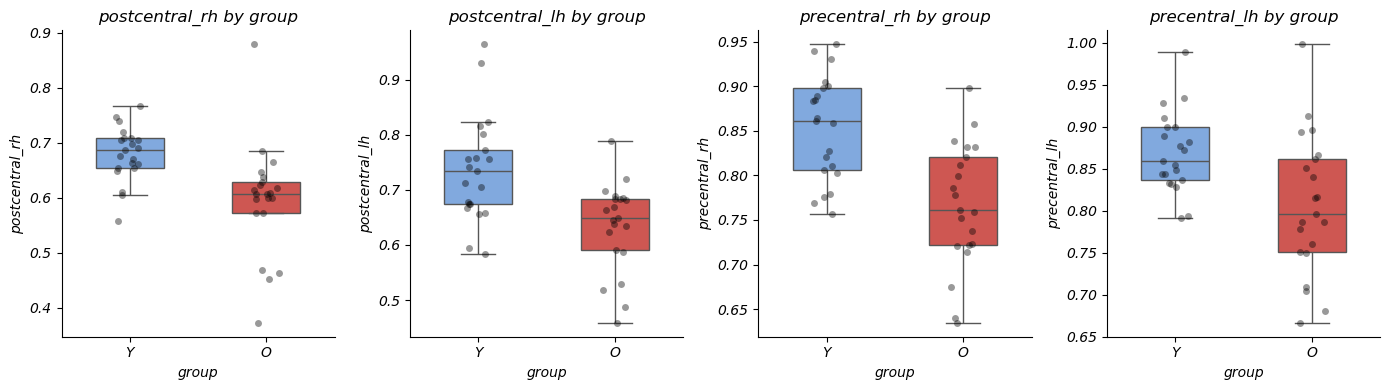

In [43]:
# distribution of the volume measures
import matplotlib.pyplot as plt
import seaborn as sns
volume_measures = ["postcentral_rh","postcentral_lh","precentral_rh","precentral_lh", ] # "CC_Posterior", "CC_Mid_Posterior", "CC_Central", "CC_Mid_Anterior", "CC_Anterior"
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()
for i, measure in enumerate(volume_measures):
    # create histogram with KDE for each volume measure, with group color coded by group
    sns.histplot(data=df_params_norm, x=measure, hue="group", palette={"O": "red", "Y": "blue"}, ax=axes[i], kde=True, element="step", stat="density")
    axes[i].set_title(f"Distribution of {measure}")
plt.tight_layout()
plt.show()  


# boxplots of the volume measures by group
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
axes = axes.flatten()
group_colors = {'Y': "#72a7ed", 'O': "#e2443e"}

for i, measure in enumerate(volume_measures):
    # create boxplot for each group, with group color coded by group, and add stripplot with the same color coding for each groupsns.boxplot(x="group", y=measure, data=df_params_norm, ax=axes[i], showfliers=False)  
    sns.boxplot(x="group", y=measure, data=df_params_norm, ax=axes[i], showfliers=False, palette=group_colors, width=0.5)  
    sns.stripplot(x="group", y=measure, data=df_params_norm, ax=axes[i], color='black', alpha=0.4, size=5, jitter=True)
    axes[i].set_title(f"{measure} by group")    

# despine the plots
sns.despine()
plt.tight_layout()
plt.show()

In [44]:
# t-test for each volume measure between groups
from scipy import stats
for measure in volume_measures:
    group_O = df_params_norm[df_params_norm['group'] == 'O'][measure]
    group_Y = df_params_norm[df_params_norm['group'] == 'Y'][measure]
    t_stat, p_value = stats.ttest_ind(group_O, group_Y)
    print(f"T-test for {measure}: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}") 

T-test for postcentral_rh: t-statistic = -3.397, p-value = 0.002
T-test for postcentral_lh: t-statistic = -3.704, p-value = 0.001
T-test for precentral_rh: t-statistic = -4.346, p-value = 0.000
T-test for precentral_lh: t-statistic = -3.017, p-value = 0.004


###  Basic correlations analysis 

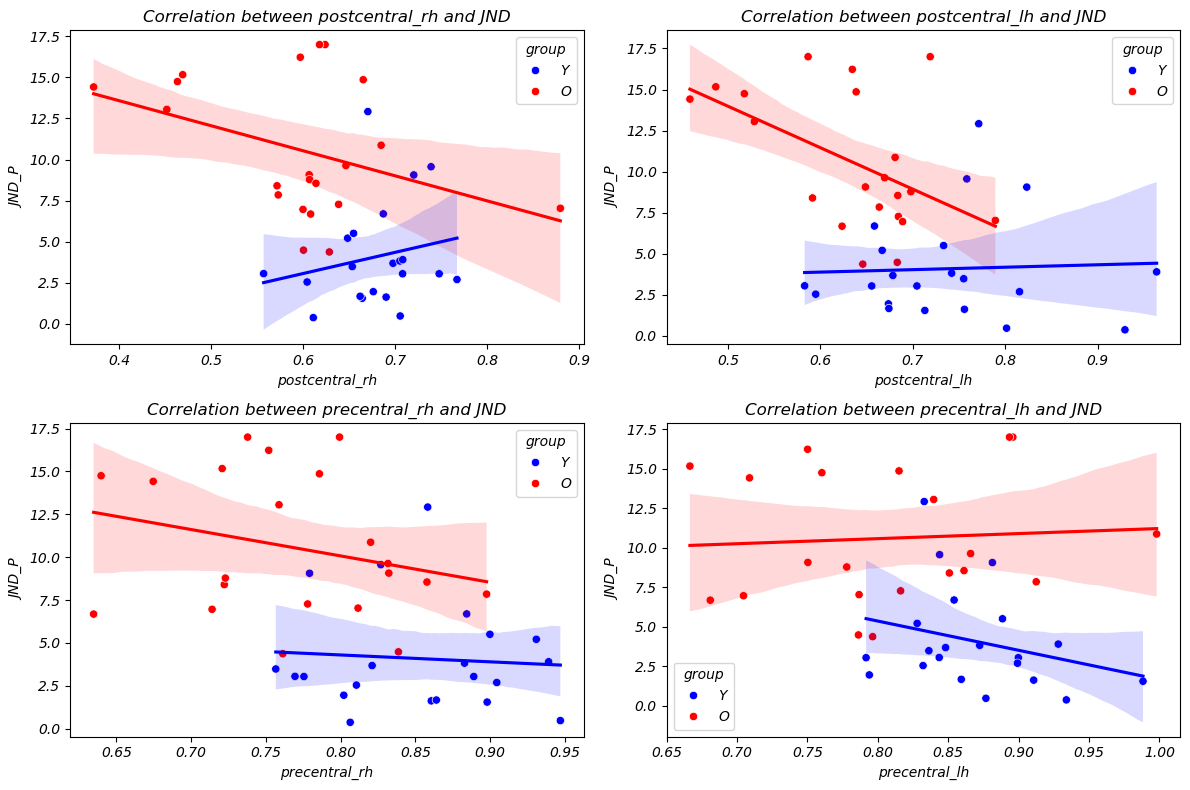

Pearson correlation between postcentral_rh and JND for group O: -0.37, p-value: 0.0947
Pearson correlation between postcentral_rh and JND for group Y: 0.20, p-value: 0.3798
Pearson correlation between postcentral_lh and JND for group O: -0.50, p-value: 0.0225
Pearson correlation between postcentral_lh and JND for group Y: 0.04, p-value: 0.8466
Pearson correlation between precentral_rh and JND for group O: -0.26, p-value: 0.2557
Pearson correlation between precentral_rh and JND for group Y: -0.07, p-value: 0.7500
Pearson correlation between precentral_lh and JND for group O: 0.06, p-value: 0.7809
Pearson correlation between precentral_lh and JND for group Y: -0.28, p-value: 0.2232


In [45]:
# correlation plots between the volume measures and the JND, for each group
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, measure in enumerate(volume_measures):   
    sns.scatterplot(x=measure, y="JND_P", hue="group", data=df_params_norm, palette={"O": "red", "Y": "blue"}, ax=axes[i])
    axes[i].set_title(f"Correlation between {measure} and JND")
    # add a regression line for each group
    sns.regplot(x=measure, y="JND_P", data=df_params_norm[df_params_norm['group'] == 'O'], scatter=False, ax=axes[i], color='red')    
    sns.regplot(x=measure, y="JND_P", data=df_params_norm[df_params_norm['group'] == 'Y'], scatter=False, ax=axes[i], color='blue')
plt.tight_layout()
plt.show()  

# print the pearson correlations with pengiuin coefficients and p values between the volume measures and the JND, for each group
from scipy.stats import pearsonr
for measure in volume_measures:
    for group in ['O', 'Y']:
        group_data = df_params_norm[df_params_norm['group'] == group]
        corr, p_value = pearsonr(group_data[measure], group_data['JND_P'])
        print(f"Pearson correlation between {measure} and JND for group {group}: {corr:.2f}, p-value: {p_value:.4f}")

Regression analysis for postcentral_rh:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.468
Method:                 Least Squares   F-statistic:                     13.01
Date:               dim., 03 mai 2026   Prob (F-statistic):           5.39e-06
Time:                        15:39:50   Log-Likelihood:                -44.248
No. Observations:                  42   AIC:                             96.50
Df Residuals:                      38   BIC:                             103.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

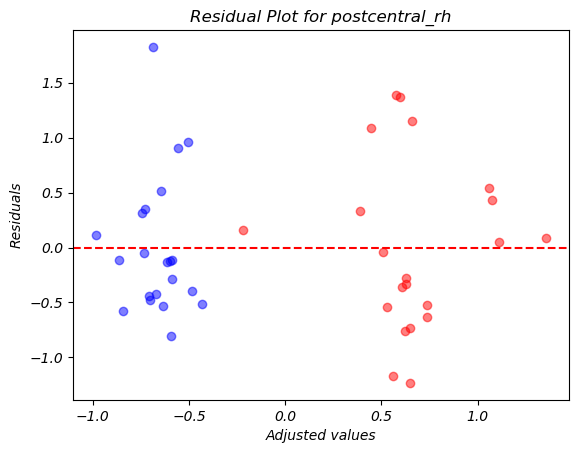

Regression analysis for postcentral_lh:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.535
Model:                            OLS   Adj. R-squared:                  0.499
Method:                 Least Squares   F-statistic:                     14.59
Date:               dim., 03 mai 2026   Prob (F-statistic):           1.78e-06
Time:                        15:39:50   Log-Likelihood:                -42.995
No. Observations:                  42   AIC:                             93.99
Df Residuals:                      38   BIC:                             100.9
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

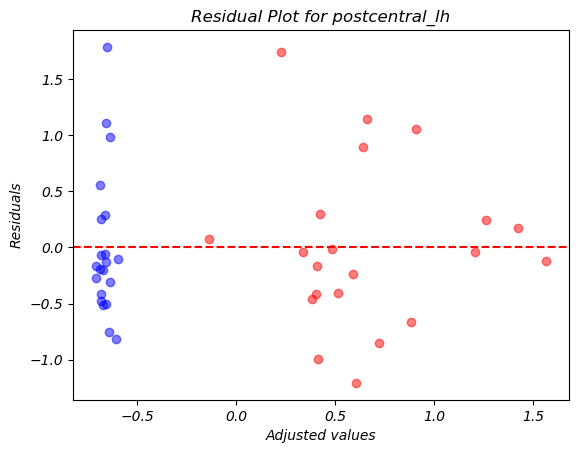

Regression analysis for precentral_rh:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.474
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     11.43
Date:               dim., 03 mai 2026   Prob (F-statistic):           1.75e-05
Time:                        15:39:50   Log-Likelihood:                -45.584
No. Observations:                  42   AIC:                             99.17
Df Residuals:                      38   BIC:                             106.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

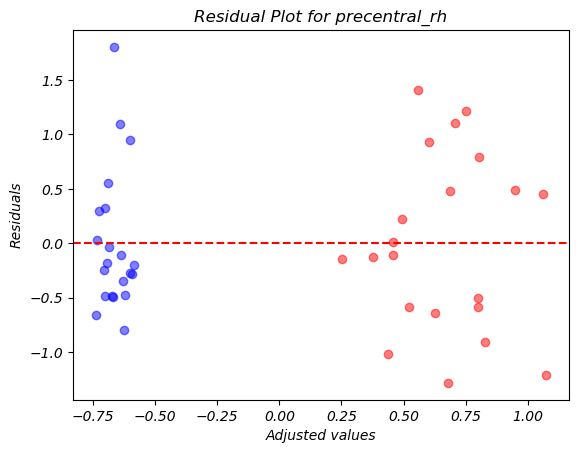

Regression analysis for precentral_lh:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.467
Model:                            OLS   Adj. R-squared:                  0.425
Method:                 Least Squares   F-statistic:                     11.10
Date:               dim., 03 mai 2026   Prob (F-statistic):           2.26e-05
Time:                        15:39:50   Log-Likelihood:                -45.876
No. Observations:                  42   AIC:                             99.75
Df Residuals:                      38   BIC:                             106.7
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------

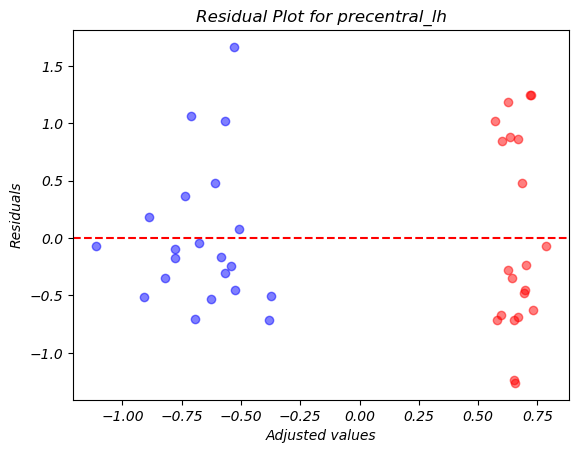

In [46]:
# regression analysis between JND and the volume measures, using statsmodels, with group as a covariate. 
# print the summary of the regression results for each model.
import statsmodels.formula.api as smf

df_params_scaled= df_params_norm.copy()

# Loop through each volume measure and perform regression analysis
for measure in volume_measures:
    # scaling and centering the volume measures
    df_params_scaled[measure] = (df_params_scaled[measure] - df_params_scaled[measure].mean()) / df_params_scaled[measure].std()
    df_params_scaled['JND_P'] = (df_params_scaled['JND_P'] - df_params_scaled['JND_P'].mean()) / df_params_scaled['JND_P'].std()
    df_params_scaled['IHD'] = (df_params_scaled['IHD'] - df_params_scaled['IHD'].mean()) / df_params_scaled['IHD'].std()

    
    formula = f"JND_P ~ {measure} * group"
    model = smf.ols(formula, data=df_params_scaled).fit()
    print(f"Regression analysis for {measure}:\n")
    print(model.summary())
    print("\n\n")   

    # color codes for groups
    group_colors = {'O': 'red', 'Y': 'blue'}
    for group, color in group_colors.items():
        mask = df_params_scaled['group'] == group
        plt.scatter(model.fittedvalues[mask], model.resid[mask], color=color, label=f"Group {group}", alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Adjusted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot for {measure}")
    plt.show()


In [47]:
# post-hoc analysis: if the interaction between the volume measure and group is significant, perform a simple slope analysis to examine the relationship between the volume measure and JND separately for each group.
volume_measure = ["postcentral_lh"]


Interaction Term -->
postcentral_lh:group[T.Y] (2.7160): This is an interaction effect. It means the relationship between postcentral_lh and JND_P differs between groups. Specifically, the negative effect of postcentral_lh on JND_P is less strong (or even reversed) for group Y compared to the reference group.

Group Differences--> Group Y has significantly lower JND_P scores than the reference group.
Brain Region Effect: Higher postcentral_lh values are associated with lower JND_P, but this effect is weaker (or reversed) for group Y.


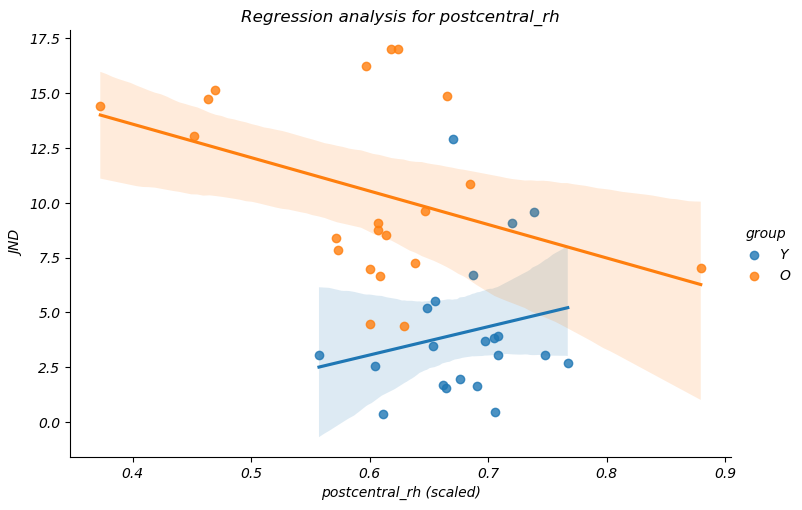

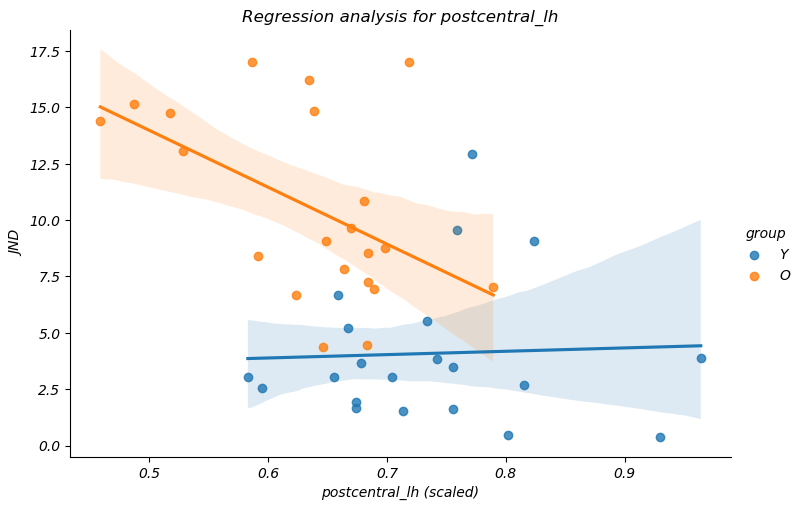

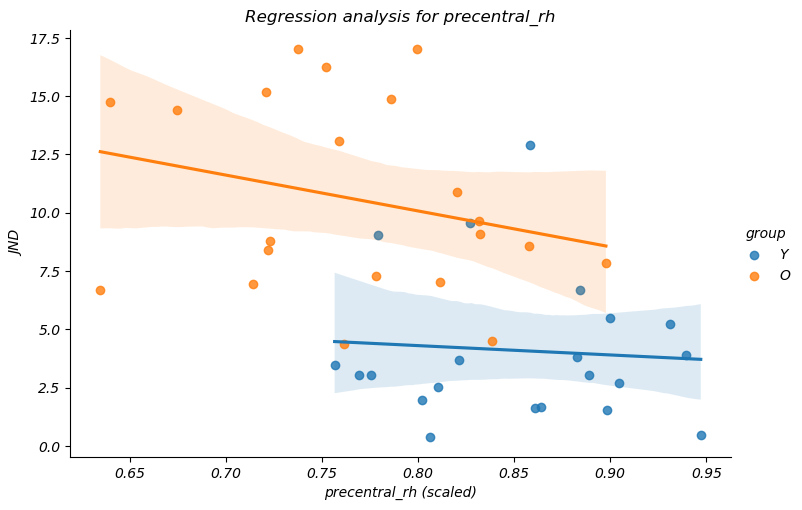

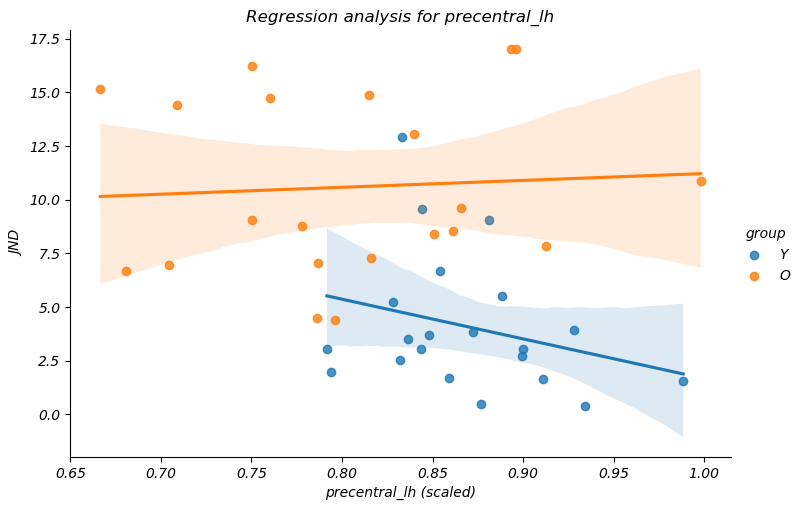

In [48]:
# plot the regression analysis results: model
# show the regression line for each group separately.

# subplots for each volume measure, with group as a hue
for measure in volume_measures:
    #figure size
    sns.lmplot(data=df_params_norm, x=measure, y="JND_P", hue="group", aspect=1.5)
    plt.title(f"Regression analysis for {measure}")
    plt.xlabel(f"{measure} (scaled)")
    plt.ylabel("JND")
    plt.show()

## Polinomial regresions


In [49]:
formula = f"JNDP ~ {measure} + np.power({measure}, 2) * group"

In [50]:
# I want to apply a quadratic regression model, to see if there is a non-linear relationship between the volume measures and JND, and if this relationship differs between groups. I will include the squared term of the volume measure and its interaction with group in the regression formula. Then I will plot the residuals to check for homoscedasticity and normality of residuals. 
# Loop through each volume measure and perform regression analysis
for measure in volume_measures:

    formula = f"JND_P ~ {measure} + np.power({measure}, 2) * group"
    model = smf.ols(formula, data=df_params_scaled).fit()
    print(f"Quadratic Regression analysis for {measure}:\n")
    print(model.summary())
    print("\n\n")   

    # color codes for groups
    group_colors = {'O': 'red', 'Y': 'blue'}
    for group, color in group_colors.items():
        mask = df_params_scaled['group'] == group
        plt.scatter(model.fittedvalues[mask], model.resid[mask], color=color, label=f"Group {group}", alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel("Adjusted values")
    plt.ylabel("Residuals")
    plt.title(f"Residual Plot for {measure}")
    plt.show()


PatsyError: Error evaluating factor: NameError: name 'np' is not defined
    JND_P ~ postcentral_rh + np.power(postcentral_rh, 2) * group
                             ^^^^^^^^^^^^^^^^^^^^^^^^^^^

# IHD analysis

In [ ]:
# regression analysis between IHD and the volume measures,
import statsmodels.formula.api as smf

# Loop through each volume measure and perform regression analysis
for measure in volume_measures:
    #scaled IHD
    df_params_scaled['IHD'] = (df_params_scaled['IHD'] - df_params_scaled['IHD'].mean()) / df_params_scaled['IHD'].std()

    formula = f"IHD ~ {measure} * group"
    model = smf.ols(formula, data=df_params_scaled).fit()
    print(f"Regression analysis for {measure}:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for postcentral_lh:

                            OLS Regression Results                            
Dep. Variable:                    IHD   R-squared:                       0.418
Model:                            OLS   Adj. R-squared:                  0.364
Method:                 Least Squares   F-statistic:                     7.674
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           0.000532
Time:                        12:19:35   Log-Likelihood:                -40.819
No. Observations:                  36   AIC:                             89.64
Df Residuals:                      32   BIC:                             95.97
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------

### Analysis of FA in the CC ROIs

In [ ]:
# read the file:  All_AgingDTI_VoxelFA.xlsx
import pandas as pd

CC_ROIs_path="/home/daniela/Documents/PROJECTS/Aging_DWI/CC_segmentation_voxel"
file_name="All_AgingDTI_Voxel_FA.xlsx"

df_CC_FA = pd.read_excel(f'{CC_ROIs_path}/{file_name}')
df_CC_FA.rename(columns={'Subject': 'sub'}, inplace=True)

# Define the path to the subject ID list and the output path for the CSV file
sub_ID_path="/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025"
sub_file_name="Subjects_Functional_Structural_Parameters.xlsx"

df_sub_ID = pd.read_excel(f'{sub_ID_path}/{sub_file_name}')

# merge the two dataframes on the 'sub' column
merged_df = pd.merge(df_sub_ID, df_CC_FA, on='sub', how='inner')

# remove variables
columns_to_remove = ['CC_Anterior', 'CC_Mid_Anterior', 'CC_Central', 'CC_Mid_Posterior', 'CC_Posterior', 'postcentral_lh', 'postcentral_rh', 'precentral_lh', 'precentral_rh', 'EstimatedTotalIntraCranialVol']
merged_df.drop(columns=columns_to_remove, inplace=True)
merged_df.head()


,sub,sex,age,group,JND_P,IHD,CC_1_ROI,CC_2_ROI,CC_3_ROI,CC_4_ROI,CC_5_ROI,CC_6_ROI,CC_7_ROI
0,sub-01,F,25,Y,9.56,0.534027,0.411479,0.666939,0.553500,0.597222,0.545191,0.617076,0.706386
1,sub-02,M,27,Y,6.69,0.570600,0.420321,0.700882,0.639006,0.648683,0.594659,0.677801,0.736987
2,sub-03,F,28,Y,12.92,-0.140120,0.388947,0.718711,0.616378,0.645037,0.635727,0.687744,0.766117
3,sub-05,F,21,Y,1.95,0.488581,0.348544,0.689371,0.584109,0.601705,0.578431,0.651975,0.753408
4,sub-06,F,25,Y,2.54,0.578001,0.457281,0.704973,0.644411,0.638733,0.666153,0.740253,0.782395


In [ ]:
# multiple regression analysis with JND as the dependent variable, and the FA values of the CC segments as independent variables, with age as a covariate.
import statsmodels.formula.api as smf

variables_to_scale = ['CC_1_ROI', 'CC_2_ROI', 'CC_3_ROI', 'CC_4_ROI', 'CC_5_ROI', 'CC_6_ROI', 'CC_7_ROI', 'JND_P', 'IHD']
df_scaled= merged_df.copy()
# scale the variables
#for var in variables_to_scale:
#    df_scaled[var] = (df_scaled[var] - df_scaled[var].mean()) / df_scaled[var].std()

# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"JND_P ~ CC_{i}_ROI * group"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   



Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.479
Model:                            OLS   Adj. R-squared:                  0.437
Method:                 Least Squares   F-statistic:                     11.63
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.50e-05
Time:                        12:19:35   Log-Likelihood:                -112.22
No. Observations:                  42   AIC:                             232.4
Df Residuals:                      38   BIC:                             239.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

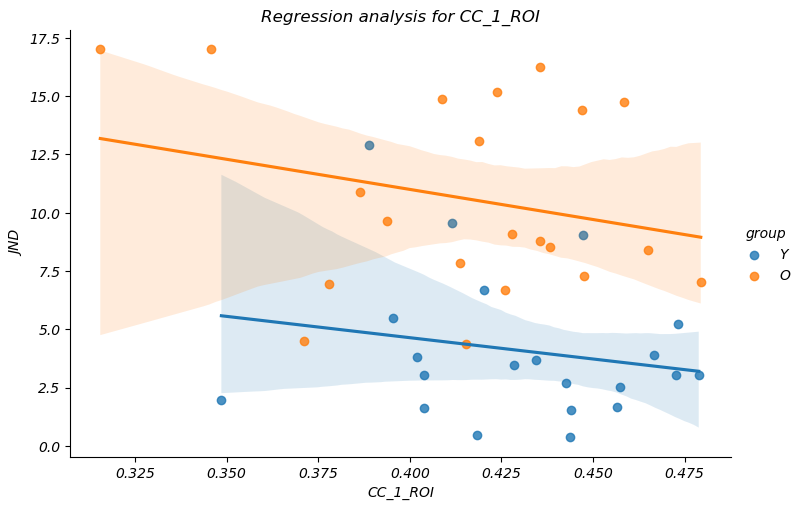

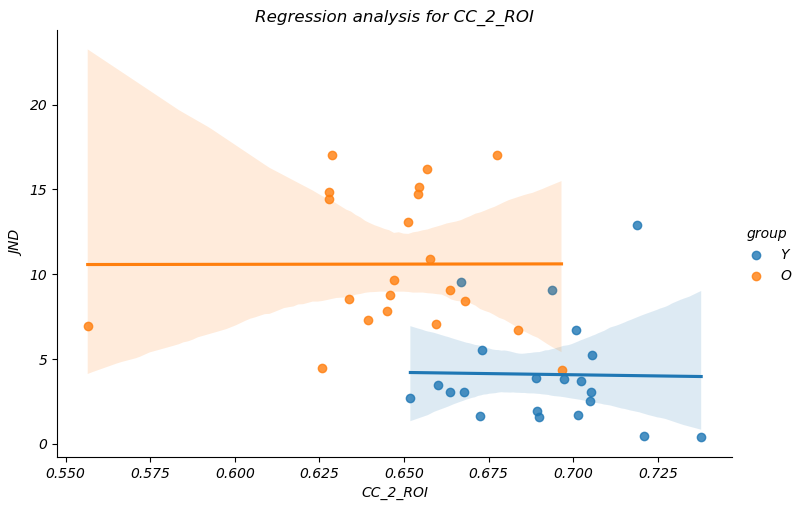

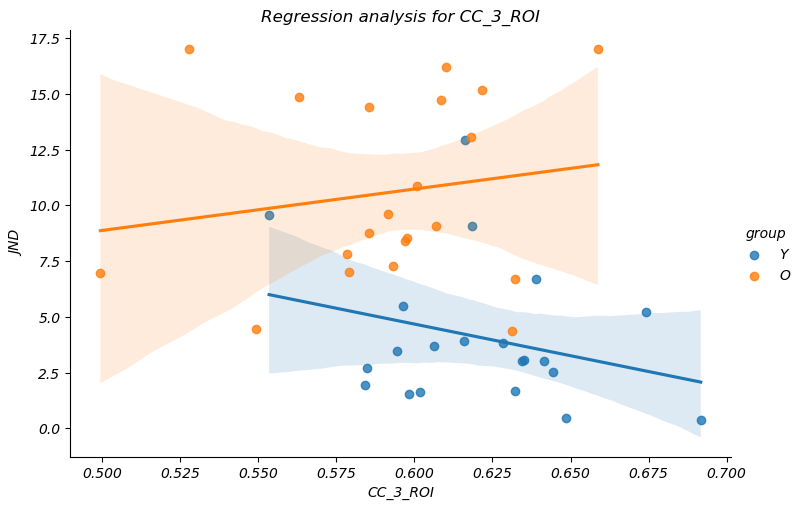

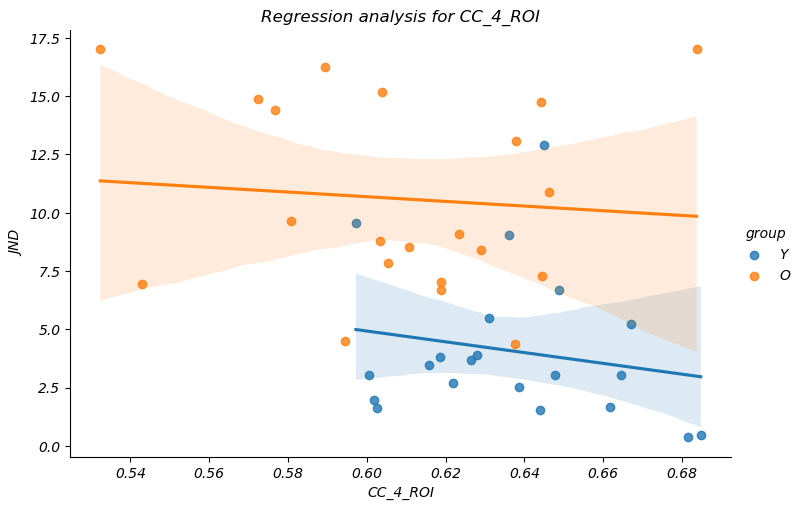

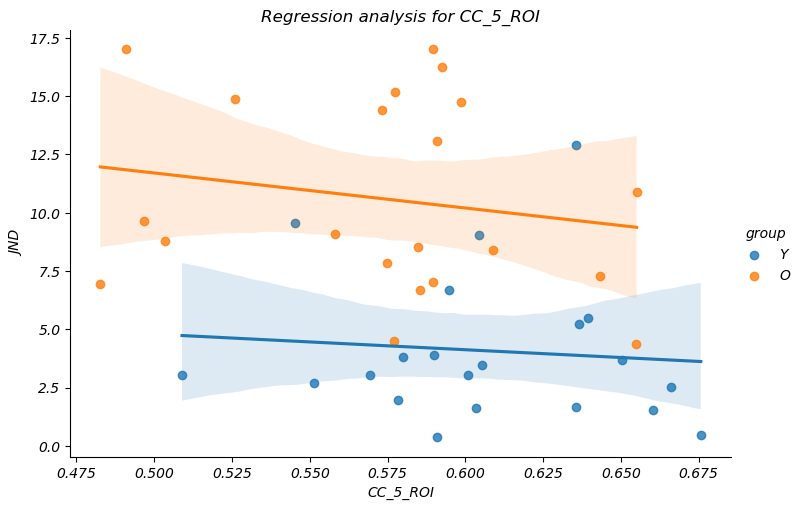

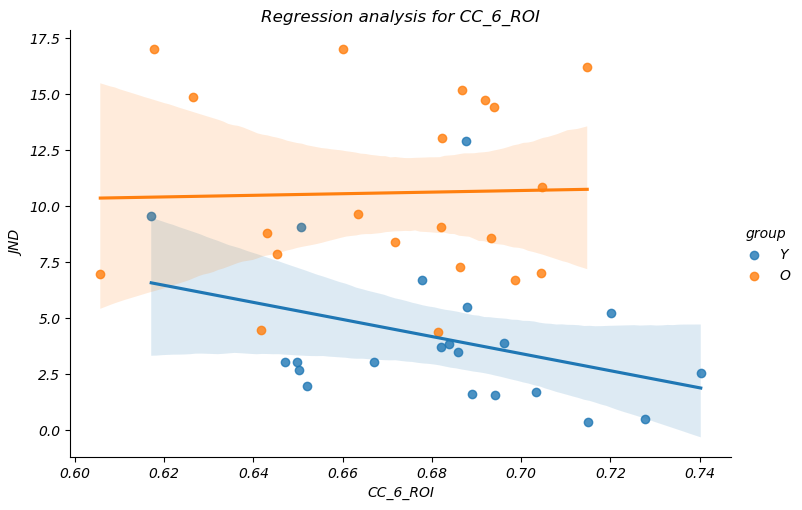

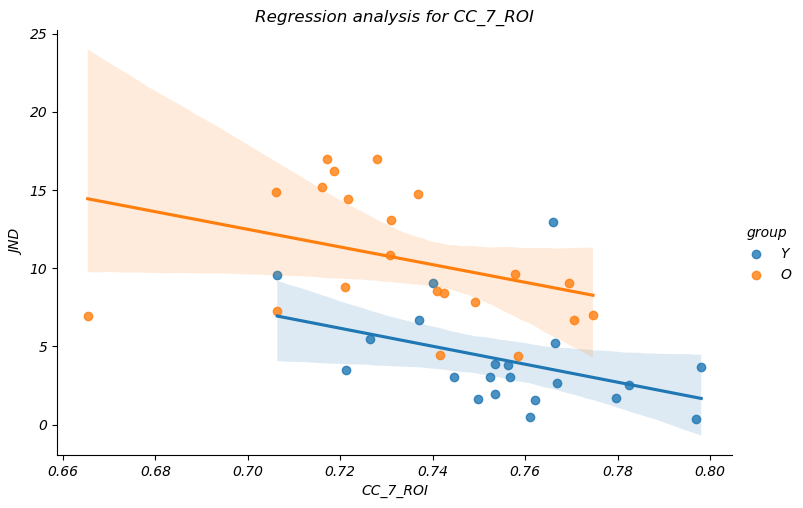

In [ ]:

# subplots for each volume measure, with group as a hue
for i in range(1, 8):
    measure = f"CC_{i}_ROI"
    #figure size
    sns.lmplot(data=df_scaled, x=measure, y="JND_P", hue="group", aspect=1.5)
    plt.title(f"Regression analysis for {measure}")
    plt.xlabel(f"{measure}")
    plt.ylabel("JND")
    plt.show()

In [ ]:
# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"JND_P ~ CC_{i}_ROI : group"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                  JND_P   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     17.45
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           3.86e-06
Time:                        12:19:39   Log-Likelihood:                -112.48
No. Observations:                  42   AIC:                             231.0
Df Residuals:                      39   BIC:                             236.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Int

In [ ]:
# regressiong for IHD
# loop across the CC segments and perform regression analysis
for i in range(1, 8):
    formula = f"IHD ~ CC_{i}_ROI * group"
    model = smf.ols(formula, data=df_scaled).fit()
    print(f"Regression analysis for CC_{i}_ROI:\n")
    print(model.summary())
    print("\n\n")   

Regression analysis for CC_1_ROI:

                            OLS Regression Results                            
Dep. Variable:                    IHD   R-squared:                       0.407
Model:                            OLS   Adj. R-squared:                  0.352
Method:                 Least Squares   F-statistic:                     7.333
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           0.000710
Time:                        12:19:39   Log-Likelihood:                -7.1745
No. Observations:                  36   AIC:                             22.35
Df Residuals:                      32   BIC:                             28.68
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------

## Mediation Model

In [ ]:
#!pip install pingouin

In [ ]:
import pandas as pd
import statsmodels.api as sm
from pingouin import mediation_analysis

df_CCs = merged_df.copy()

for i in range(1, 8):
    cc_FA_ROIs = f"CC_{i}_ROI"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'JND': df_CCs["JND_P"],
        'IHD': df_CCs["IHD"],
        'CCvar': df_CCs[cc_FA_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='age', y='JND', m='CCvar', seed=42)
    print(f"Results for {cc_FA_ROIs}:")
    print(mediation_results)
    print("\n")

Results for CC_1_ROI:
        path       coef         se          pval      CI2.5    CI97.5  sig
0  CCvar ~ X  -0.000271   0.000243  2.719798e-01  -0.000763  0.000221   No
1  Y ~ CCvar -39.671139  20.053911  5.481958e-02 -80.201605  0.859328   No
2      Total   0.145284   0.023485  2.585873e-07   0.097819  0.192748  Yes
3     Direct   0.138698   0.023372  6.389860e-07   0.091423  0.185973  Yes
4   Indirect   0.006585   0.009349  3.000000e-01  -0.001944  0.036750   No


Results for CC_2_ROI:
        path       coef         se          pval       CI2.5     CI97.5  sig
0  CCvar ~ X  -0.000898   0.000172  5.948936e-06   -0.001246  -0.000550  Yes
1  Y ~ CCvar -65.618941  20.841866  3.099823e-03 -107.741925 -23.495958  Yes
2      Total   0.145284   0.023485  2.585873e-07    0.097819   0.192748  Yes
3     Direct   0.145110   0.030827  3.140447e-05    0.082756   0.207464  Yes
4   Indirect   0.000173   0.026607  9.640000e-01   -0.053095   0.053374   No


Results for CC_3_ROI:
        path      

In [ ]:
# interation between CC and JND, mediated by age

for i in range(1, 8):
    cc_FA_ROIs = f"CC_{i}_ROI"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'IHD': df_CCs["IHD"],
        'JND': df_CCs["JND_P"],
        'group': df_CCs["group"],
        'CCvar': df_CCs[cc_FA_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='CCvar', y='JND', m='age', seed=42)
    print(f"Results for {cc_FA_ROIs}:")
    print(mediation_results)
    print("\n")

Results for CC_1_ROI:
       path        coef         se          pval       CI2.5     CI97.5  sig
0   age ~ X -110.939886  99.597795  2.719798e-01 -312.234538  90.354766   No
1   Y ~ age    0.145284   0.023485  2.585873e-07    0.097819   0.192748  Yes
2     Total  -39.671139  20.053911  5.481958e-02  -80.201605   0.859328   No
3    Direct  -24.283975  14.949038  1.123355e-01  -54.521258   5.953308   No
4  Indirect  -15.387164  12.320373  2.120000e-01  -38.429050   9.454298   No


Results for CC_2_ROI:
       path        coef         se          pval       CI2.5      CI97.5  sig
0   age ~ X -450.870394  86.452109  5.948936e-06 -625.596625 -276.144163  Yes
1   Y ~ age    0.145284   0.023485  2.585873e-07    0.097819    0.192748  Yes
2     Total  -65.618941  20.841866  3.099823e-03 -107.741925  -23.495958  Yes
3    Direct   -0.192971  21.847005  9.929975e-01  -44.382710   43.996768   No
4  Indirect  -65.425971  22.020491  0.000000e+00 -119.196248  -33.687308  Yes


Results for CC_3_ROI:


## Analysis of Diffusion metrics in the CC ROIs

In [ ]:
import pandas as pd

# Define paths
CC_ROIs_path = "/home/daniela/Documents/PROJECTS/Aging_DWI/CC_segmentation_voxel"
sub_ID_path = "/home/daniela/Documents/PROJECTS/Aging_DWI/CEDRE/CorrectedTracts2025"
sub_file_name = "Subjects_Functional_Structural_Parameters.xlsx"

# Columns to remove after merging
columns_to_remove = [
    'CC_Anterior', 'CC_Mid_Anterior', 'CC_Central',
    'CC_Mid_Posterior', 'CC_Posterior',
    'postcentral_lh', 'postcentral_rh',
    'precentral_lh', 'precentral_rh',
    'EstimatedTotalIntraCranialVol'
]

# Load subject ID data once
df_sub_ID = pd.read_excel(f"{sub_ID_path}/{sub_file_name}")

# Define a function to load and merge data for each metric
def load_and_merge_data(metric):
    file_name = f"All_AgingDTI_Voxel_{metric}.xlsx"
    df_CC = pd.read_excel(f"{CC_ROIs_path}/{file_name}")
    df_CC.rename(columns={'Subject': 'sub'}, inplace=True)
    merged_df = pd.merge(df_sub_ID, df_CC, on='sub', how='inner')
    merged_df.drop(columns=columns_to_remove, inplace=True)
    return merged_df

# Load and merge data for all metrics
metrics = ['MD', 'RD', 'AD']
merged_dfs = {metric: load_and_merge_data(metric) for metric in metrics}

# Access the merged dataframes as:
# merged_dfs['MD'], merged_dfs['RD'], merged_dfs['AD']
merged_dfs['RD']

,sub,sex,age,group,JND_P,IHD,CC_1_ROI,CC_2_ROI,CC_3_ROI,CC_4_ROI,CC_5_ROI,CC_6_ROI,CC_7_ROI
0,sub-01,F,25,Y,9.5600,0.534027,0.000530,0.000345,0.000407,0.000379,0.000429,0.000372,0.000324
1,sub-02,M,27,Y,6.6900,0.570600,0.000494,0.000300,0.000345,0.000336,0.000407,0.000319,0.000267
2,sub-03,F,28,Y,12.9200,-0.140120,0.000567,0.000297,0.000344,0.000327,0.000351,0.000333,0.000270
3,sub-05,F,21,Y,1.9500,0.488581,0.000608,0.000312,0.000387,0.000382,0.000419,0.000346,0.000287
4,sub-06,F,25,Y,2.5400,0.578001,0.000466,0.000292,0.000335,0.000335,0.000347,0.000304,0.000267
5,sub-08,F,67,O,4.4800,0.419239,0.000565,0.000365,0.000426,0.000386,0.000419,0.000379,0.000294
6,sub-09,M,73,O,9.6300,0.246470,0.000525,0.000361,0.000404,0.000409,0.000480,0.000333,0.000258
7,sub-10,F,64,O,7.2700,0.253942,0.000527,0.000365,0.000378,0.000328,0.000314,0.000312,0.000322
8,sub-11,F,21,Y,1.6200,0.268078,0.000560,0.000350,0.000386,0.000383,0.000400,0.000342,0.000284
9,sub-12,M,21,Y,3.6800,0.115833,0.000512,0.000312,0.000386,0.000366,0.000361,0.000367,0.000244


In [ ]:
import statsmodels.api as sm
from pingouin import mediation_analysis

df_CCs = merged_dfs['RD'].copy()

for i in range(1, 8): 
    cc_ROIs = f"CC_{i}_ROI"  # Use a single string for the current region
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'JND': df_CCs["JND_P"],
        'IHD': df_CCs["IHD"],
        'CCvar': df_CCs[cc_ROIs],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='CCvar', y='JND', m='age', seed=42)
    print(f"Results for {cc_ROIs}:")
    print(mediation_results)
    print("\n")


Results for CC_1_ROI:
       path           coef            se          pval         CI2.5  \
0   age ~ X  190385.016022  46780.942660  2.154191e-04  95837.204075   
1   Y ~ age       0.145284      0.023485  2.585873e-07      0.097819   
2     Total   43804.554248   9253.093302  2.752103e-05  25103.355090   
3    Direct   22829.687425   9254.828543  1.813135e-02   4110.029764   
4  Indirect   20974.866822   6257.023282  0.000000e+00  10663.987854   

          CI97.5  sig  
0  284932.827968  Yes  
1       0.192748  Yes  
2   62505.753405  Yes  
3   41549.345086  Yes  
4   37208.230573  Yes  


Results for CC_2_ROI:
       path           coef            se          pval          CI2.5  \
0   age ~ X  404653.460646  69391.612234  8.156375e-07  264407.780866   
1   Y ~ age       0.145284      0.023485  2.585873e-07       0.097819   
2     Total   71723.088010  15999.274257  6.048404e-05   39387.348548   
3    Direct   23928.977269  18928.036023  2.136590e-01  -14356.589328   
4  Indirect 

In [ ]:
# mediation model with volumetric measures, using the normalized values.
# from the data frame : df_params_norm

variables_volumetric = ["postcentral_lh", "precentral_lh", "postcentral_rh", "precentral_rh"]

for i in range(1, 5):
    data = pd.DataFrame({
        'age': df_CCs["age"],
        'IHD': df_CCs["IHD"],
        'JND': df_CCs["JND_P"],
        'VolVar': df_params_norm[variables_volumetric[i-1]],
    })
    # Mediation analysis
    mediation_results = mediation_analysis(data=data, x='age', y='JND', m='VolVar', seed=42)
    print(f"Results for {variables_volumetric[i-1]}:")
    print(mediation_results)
    print("\n")

Results for postcentral_lh:
         path         coef          se          pval        CI2.5  \
0  VolVar ~ X    -0.000023    0.000006  2.044634e-04    -0.000035   
1  Y ~ VolVar -2359.377046  666.631667  1.034311e-03 -3706.689904   
2       Total     0.145284    0.023485  2.585873e-07     0.097819   
3      Direct     0.127887    0.027849  4.492585e-05     0.071558   
4    Indirect     0.017397    0.015093  2.280000e-01    -0.010030   

        CI97.5  sig  
0    -0.000012  Yes  
1 -1012.064189  Yes  
2     0.192748  Yes  
3     0.184216  Yes  
4     0.048690   No  


Results for precentral_lh:
         path         coef          se          pval        CI2.5     CI97.5  \
0  VolVar ~ X    -0.000014    0.000004  3.001712e-03    -0.000023  -0.000005   
1  Y ~ VolVar -2082.760605  992.388594  4.219971e-02 -4088.452770 -77.068440   
2       Total     0.145284    0.023485  2.585873e-07     0.097819   0.192748   
3      Direct     0.145005    0.026588  2.966138e-06     0.091226   0.198783